In [1]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
import sklearn
from sklearn.preprocessing import MinMaxScaler


In [3]:
dm = np.genfromtxt('dis_matrix.csv', delimiter=',')
scaler = MinMaxScaler()
dm = scaler.fit_transform(dm)
projected_data = np.mean(dm, axis=1)
clusterer = sklearn.cluster.DBSCAN(eps=0.6, min_samples=3, metric='precomputed')
mapper = km.KeplerMapper(verbose=0)


In [4]:
import numpy as np
import time

N_SAMPLES = 50
SEED = 42
N_LB, N_UB = 10, 20
OUTPUT_FILE = 'results_output_covid_random.txt'

rng = np.random.default_rng(SEED)
n_candidates = rng.integers(N_LB, N_UB + 1, size=N_SAMPLES)
p_candidates = rng.uniform(0.1, 0.7, size=N_SAMPLES)

best_tsc = -np.inf
best_n, best_p, best_iter = None, None, 0

start_time = time.time()
for i, (n_val, p_val) in enumerate(zip(n_candidates, p_candidates)):
    n = int(n_val)
    p = float(p_val)
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=p)
        graph = mapper.map(projected_data, dm, clusterer=clusterer, cover=cover, precomputed=True)
        tsc = evaluate.compute_SC_adj(dm, projected_data, graph, Cover=cover, type='k', precompute=True)
    except Exception:
        tsc = 0.0
    if tsc > best_tsc:
        best_tsc = tsc
        best_n, best_p, best_iter = n, p, i
total_time = time.time() - start_time
convergence_time = total_time * (best_iter + 1) / N_SAMPLES

with open(OUTPUT_FILE, 'a') as f:
    f.write("=== Random-Mapper ===\n")
    f.write(f"Best n: {best_n}\n")
    f.write(f"Best a: {round(best_p, 3)}\n")
    f.write(f"Best TSC: {round(best_tsc, 4)}\n")
    f.write(f"Convergence iteration: {best_iter}\n")
    f.write(f"Convergence time: {convergence_time:.4f}s\n")
    f.write(f"Total time: {total_time:.4f}s\n\n")

print(f"Best N={best_n}, p={round(best_p, 3)}, TSC={round(best_tsc, 4)}")
print(f"Found at iteration {best_iter}, convergence_time={convergence_time:.4f}s, total={total_time:.4f}s")


100%|██████████| 100/100 [00:00<00:00, 102.21it/s]


SC:0.118720801
SC_norm:0.5593604005
TSR:0.5
SC_adj:0.5296802002500001


100%|██████████| 100/100 [00:00<00:00, 105.51it/s]


SC:-0.0127408075807
SC_norm:0.49362959620965
TSR:0.5
SC_adj:0.496814798104825


100%|██████████| 100/100 [00:00<00:00, 121.27it/s]


...

SC:-0.06711802713220136
SC_norm:0.4664409864338993
TSR:0.06666666666666667
SC_adj:0.266553826550283


100%|██████████| 100/100 [00:00<00:00, 112.94it/s]


SC:0.0091769291158
SC_norm:0.5045884645579
TSR:0.3333333333333333
SC_adj:0.4189608989456166


100%|██████████| 100/100 [00:00<00:00, 118.25it/s]

SC:0.025345732739
SC_norm:0.5126728663695
TSR:0.5
SC_adj:0.50633643318475
Best N=10, p=0.217, TSC=0.5297
Found at iteration 0, convergence_time=0.9461s, total=47.3037s


# Random-Mapper — Final Graph

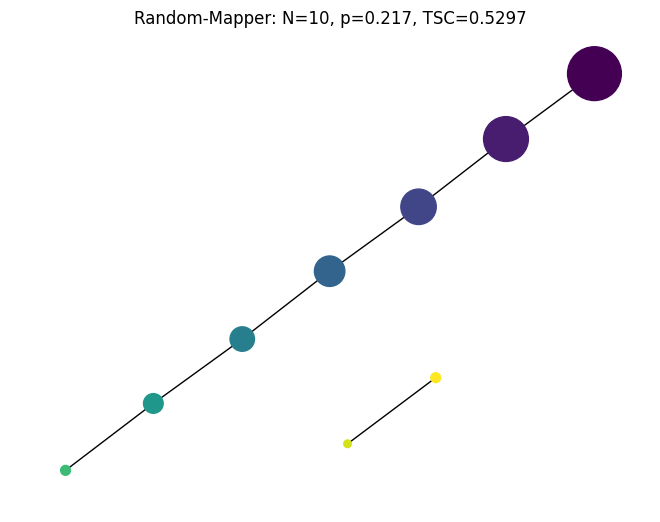

100%|██████████| 100/100 [00:00<00:00, 171.50it/s]

SC:0.118720801
SC_norm:0.5593604005
TSR:0.5
SC_adj:0.5296802002500001


0.5296802002500001

In [5]:
cover = km.Cover(n_cubes=best_n, perc_overlap=best_p)
graph = mapper.map(projected_data, dm, clusterer=clusterer, cover=cover, precomputed=True)

color_list = [np.mean(projected_data[list(v)]) for v in graph['nodes'].values()]
size_list  = [10 * len(list(v)) for v in graph['nodes'].values()]
G = km.adapter.to_networkx(graph)
nx.draw(G, pos=nx.kamada_kawai_layout(G), node_color=color_list, node_size=size_list, cmap='viridis')
plt.title(f"Random-Mapper: N={best_n}, p={round(best_p,3)}, TSC={round(best_tsc,4)}")
plt.savefig('random_mapper_covid19.png', bbox_inches='tight')
plt.show()

evaluate.compute_SC_adj(dm, projected_data, graph, Cover=cover, type='k', precompute=True)
